<a href="https://colab.research.google.com/github/Sagarkumarpradhan053/Customer-Churn-Analysis/blob/main/Customer_Churn_Analysys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# 1. Paste your file ID here (replace the placeholder)
file_id = '1kRZ1H-qmN9HLU2NiLdqniam8KMPT0IFk'
# 2. Create the direct download URL
url = f'https://drive.google.com/uc?export=download&id={file_id}'
# 3. Read the CSV into a DataFrame
df = pd.read_csv(url)
# View the first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
#replacing blanks with 0 as tenure is 0 and ni total charges are recorded

In [12]:

df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
# here isnull gices if there any null value present or not and .sum give the overall null value

In [15]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [17]:
# if there any duplicated data

In [18]:
df["customerID"].duplicated().sum()

np.int64(0)

In [19]:
def conv(value):
  if value == 1:
    return "yes"
  else:
    return "no"
df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

In [20]:
# converted senior citizen value 0/1 to no/yes


In [21]:
df.head(30)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,no,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,no,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,no,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,no,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,no,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


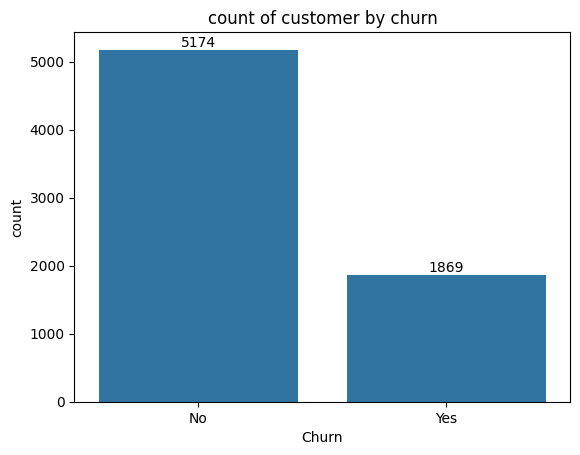

In [22]:
ax = sns.countplot(x = 'Churn' , data = df)

ax.bar_label(ax.containers[0])
plt.title("count of customer by churn")
plt.show()

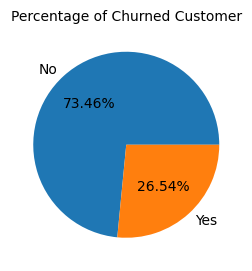

In [23]:
plt.figure(figsize=(3,5))
gb = df.groupby("Churn").agg({'Churn':'count'})
gb
plt.pie(gb['Churn'] , labels = gb.index , autopct="%1.2f%%")
plt.title("Percentage of Churned Customer", fontsize = 10)
plt.show()

In [24]:
#from the given piechart we can conclude that 26.54% of our customers churned out
#now lets explore reason behind it

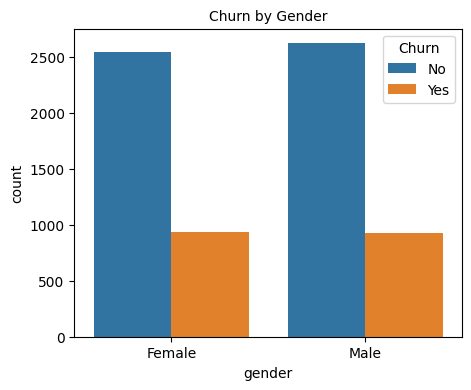

In [25]:
plt.figure(figsize=(5,4))
sns.countplot(x =df["gender"],data = df, hue = "Churn")
plt.title("Churn by Gender", fontsize = 10)
plt.show()

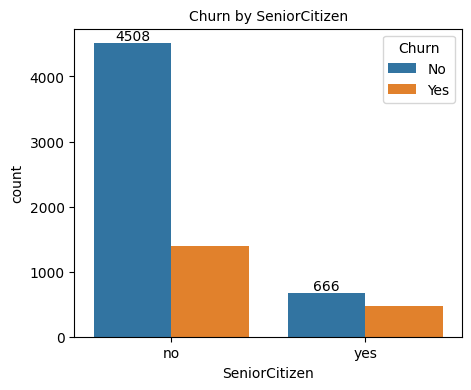

In [26]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x =df["SeniorCitizen"],data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Churn by SeniorCitizen", fontsize = 10)
plt.show()
#comparative a greater nujmber of senior citizen has churned out

In [27]:
# How many senior citizen churned out in percentage

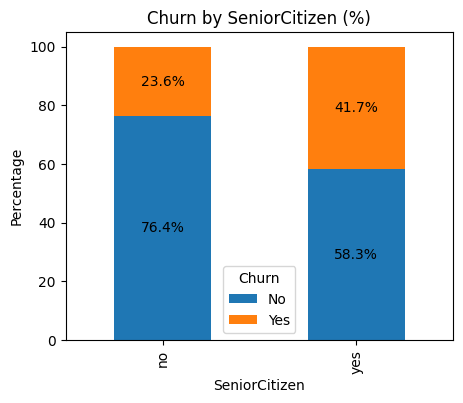

In [28]:


# Create percentage table
churn_percent = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"   # percentage within each SeniorCitizen group
) * 100

# Plot stacked bar chart
ax = churn_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(5,4)
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center'
    )

plt.title("Churn by SeniorCitizen (%)")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

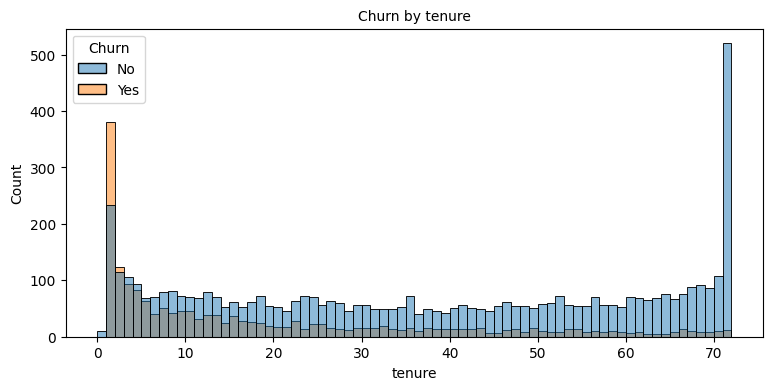

In [29]:
plt.figure(figsize=(9,4))
sns.histplot(x="tenure", data = df, bins = 72,hue = "Churn")
plt.title("Churn by tenure", fontsize = 10)
plt.show()

In [30]:
# People who have used for longtime have stayed and for 2 or 3 months have churned out

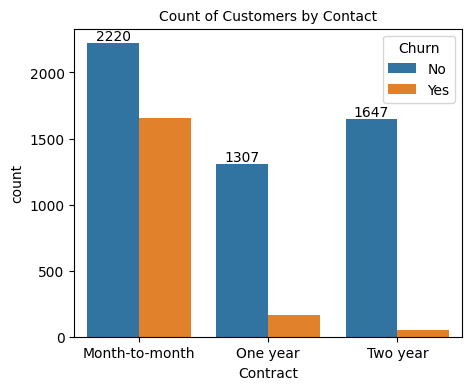

In [31]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x =df["Contract"],data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contact", fontsize = 10)
plt.show()

In [32]:
# People who have month to month contract are likely to churn then from these who have 1 or 2 years of contract

In [33]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

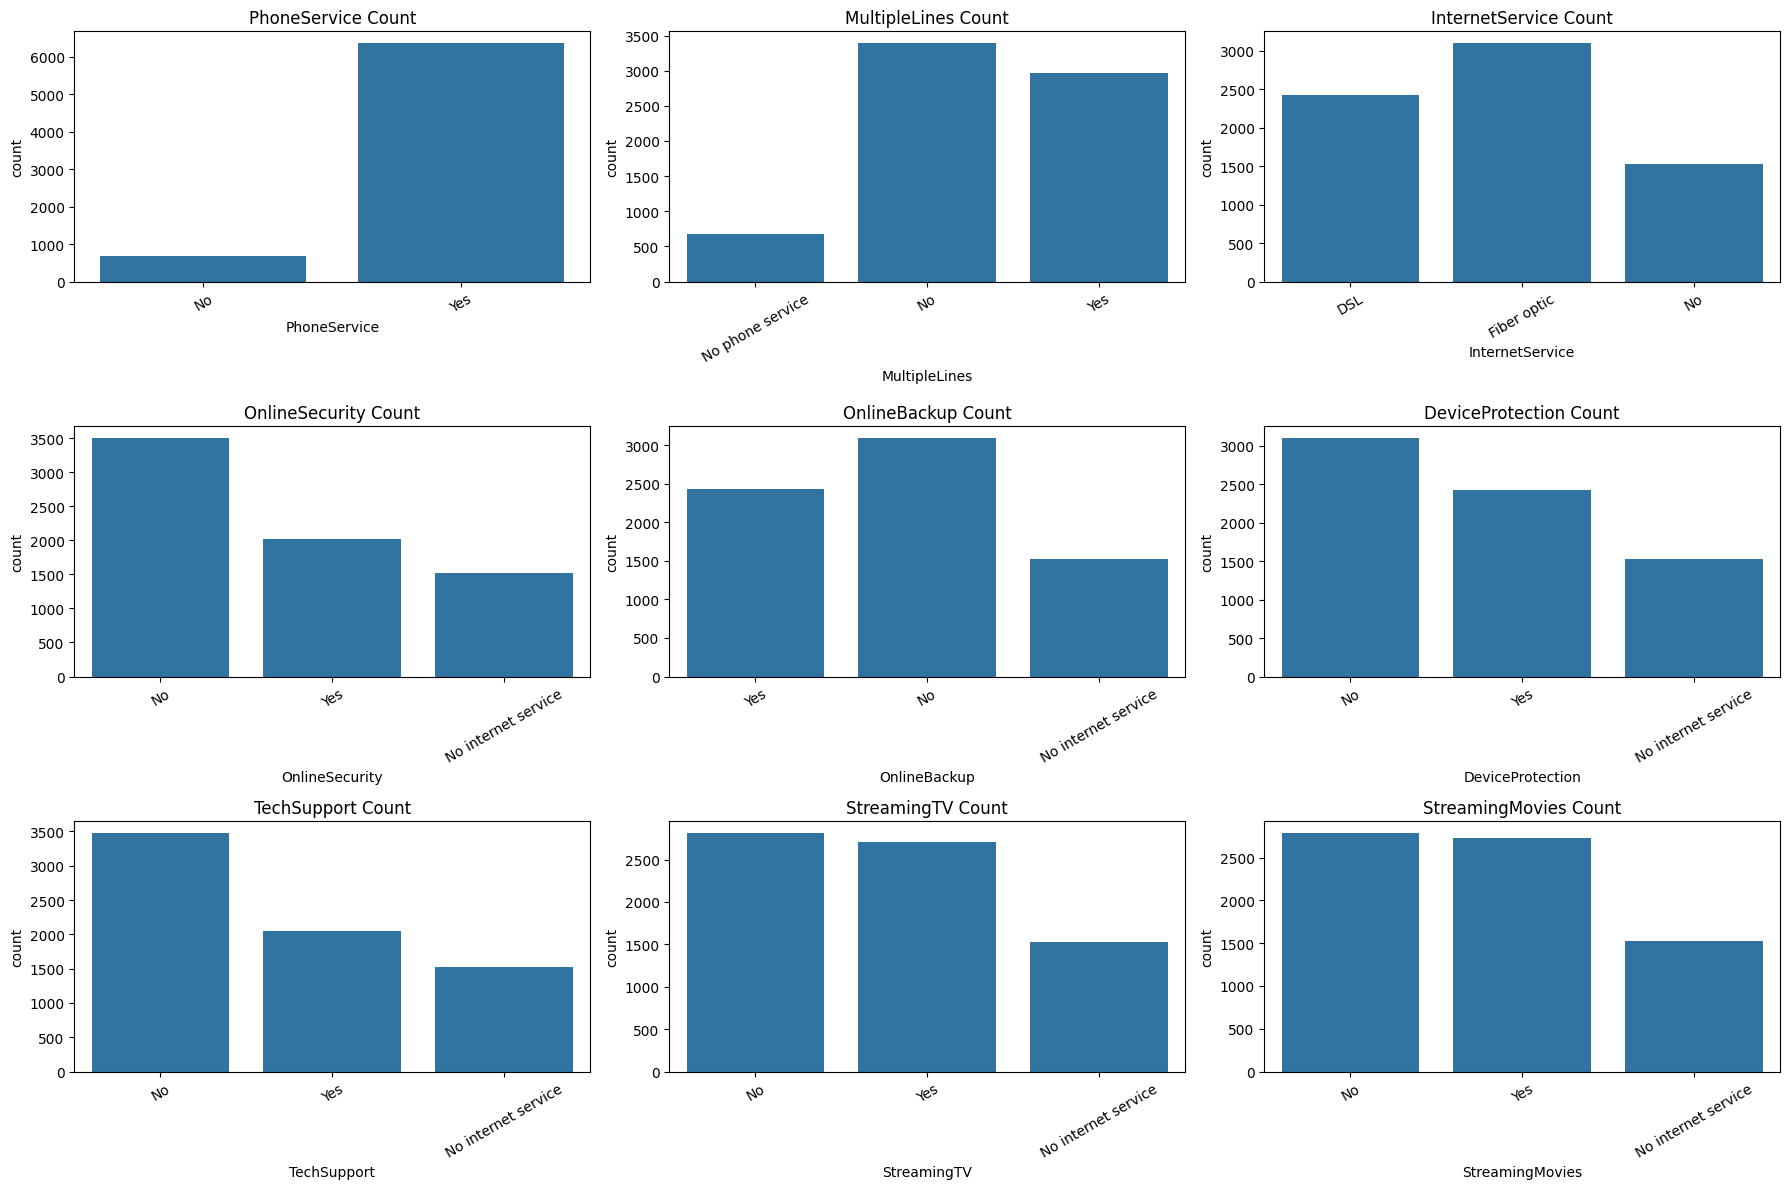

In [34]:
columns = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Create subplot grid (3 rows × 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

axes = axes.flatten()  # Convert to 1D array for looping

for i, col in enumerate(columns):
    sns.countplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(f"{col} Count")
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [35]:
# The visualization present count plots showing customer churn across various service fearture

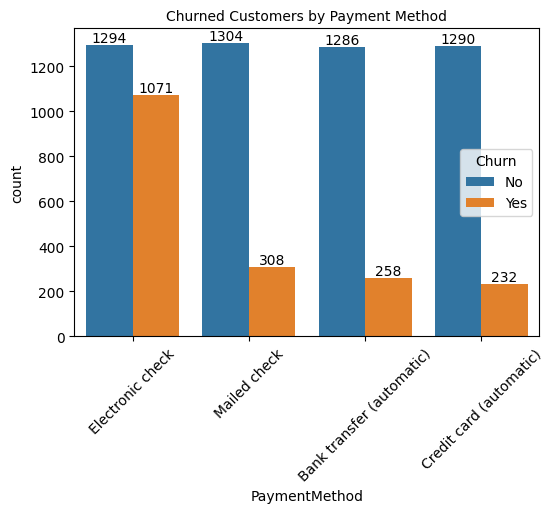

In [36]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x =df["PaymentMethod"],data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Payment Method", fontsize = 10)
plt.xticks(rotation = 45)
plt.show()

In [37]:
# customer likely to churn when he is using electronic check as a payment method